# Machine Learning Capstone Project

## Seoul Bike Sharing Demand

### Review 1 - Regression Track

**Objective:** Predict hourly rented bike demand using environmental, weather, and time-related features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


# 1. Dataset Loading

The Seoul Bike Sharing Demand dataset is loaded into a Pandas DataFrame for further analysis.

In [2]:
df = pd.read_csv("SeoulBikeData.csv", encoding="latin1")

# 2. Dataset Overview

The dataset dimensions, column names, data types, and general information are examined to understand the structure of the dataset.

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

Number of rows: 8760
Number of columns: 14

Column names:
['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day']

Data types:
Date                             str
Rented Bike Count              int64
Hour                           int64
Temperature(°C)              float64
Humidity(%)                    int64
Wind speed (m/s)             float64
Visibility (10m)               int64
Dew point temperature(°C)    float64
Solar Radiation (MJ/m2)      float64
Rainfall(mm)                 float64
Snowfall (cm)                float64
Seasons                          str
Holiday                          str
Functioning Day                  str
dtype: object

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-N

# 3. Initial Data Inspection

The first and last few records are displayed to understand the values and structure of the observations.

In [4]:
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

First 5 rows:


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes



Last 5 rows:


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes
8759,30/11/2018,584,23,1.9,43,1.3,1909,-9.3,0.0,0.0,0.0,Autumn,No Holiday,Yes


# 4. Descriptive Statistics

Descriptive statistics are generated for numerical and categorical variables to understand their distributions and ranges.

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,8760,365,01/12/2017,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rented Bike Count,8760.0,NaN,NaN,NaN,704.602055,644.997468,0.0,191.0,504.5,1065.25,3556.0
Hour,8760.0,NaN,NaN,NaN,11.5,6.922582,0.0,5.75,11.5,17.25,23.0
Temperature(°C),8760.0,NaN,NaN,NaN,12.882922,11.944825,-17.8,3.5,13.7,22.5,39.4
Humidity(%),8760.0,NaN,NaN,NaN,58.226256,20.362413,0.0,42.0,57.0,74.0,98.0
Wind speed (m/s),8760.0,NaN,NaN,NaN,1.724909,1.0363,0.0,0.9,1.5,2.3,7.4
Visibility (10m),8760.0,NaN,NaN,NaN,1436.825799,608.298712,27.0,940.0,1698.0,2000.0,2000.0
Dew point temperature(°C),8760.0,NaN,NaN,NaN,4.073813,13.060369,-30.6,-4.7,5.1,14.8,27.2
Solar Radiation (MJ/m2),8760.0,NaN,NaN,NaN,0.569111,0.868746,0.0,0.0,0.01,0.93,3.52
Rainfall(mm),8760.0,NaN,NaN,NaN,0.148687,1.128193,0.0,0.0,0.0,0.0,35.0


# 5. Missing Value Analysis

Missing values are checked for every column before model development.

In [6]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": (missing / len(df)) * 100
})

missing_df

,Missing Values,Missing Percentage
Date,0,0.0
Rented Bike Count,0,0.0
Hour,0,0.0
Temperature(°C),0,0.0
Humidity(%),0,0.0
Wind speed (m/s),0,0.0
Visibility (10m),0,0.0
Dew point temperature(°C),0,0.0
Solar Radiation (MJ/m2),0,0.0
Rainfall(mm),0,0.0


# 6. Duplicate Analysis

The dataset is checked for duplicate observations to ensure that repeated records do not affect model training.

In [7]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


# 7. Target Variable

The target variable for the regression problem is **Rented Bike Count**.

The objective is to predict the number of rented bikes using the available features.

In [8]:
target = "Rented Bike Count"

print("Target variable:", target)
print("\nTarget statistics:")
print(df[target].describe())

Target variable: Rented Bike Count

Target statistics:
count    8760.000000
mean      704.602055
std       644.997468
min         0.000000
25%       191.000000
50%       504.500000
75%      1065.250000
max      3556.000000
Name: Rented Bike Count, dtype: float64


# 8. Target Distribution

The distribution of the target variable is visualised to understand the spread of hourly bike rental demand.

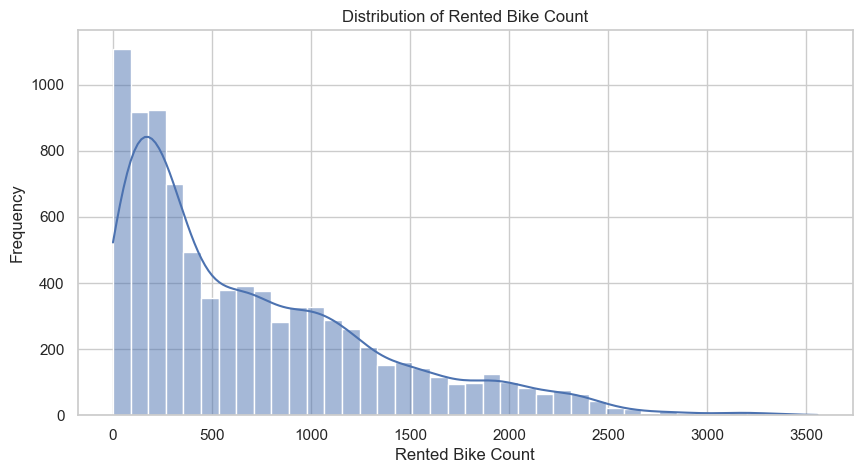

In [9]:
plt.figure(figsize=(10, 5))

sns.histplot(df[target], bins=40, kde=True)

plt.title("Distribution of Rented Bike Count")
plt.xlabel("Rented Bike Count")
plt.ylabel("Frequency")
plt.show()

### Observation

The target variable shows variation in hourly bike rental demand, with some periods having substantially higher rental counts than others. The distribution is not perfectly symmetric, indicating that bike demand varies considerably across different time periods.

# 9. Numerical Feature Distributions

The distributions of numerical variables are visualised to identify their ranges, spread, and possible skewness.

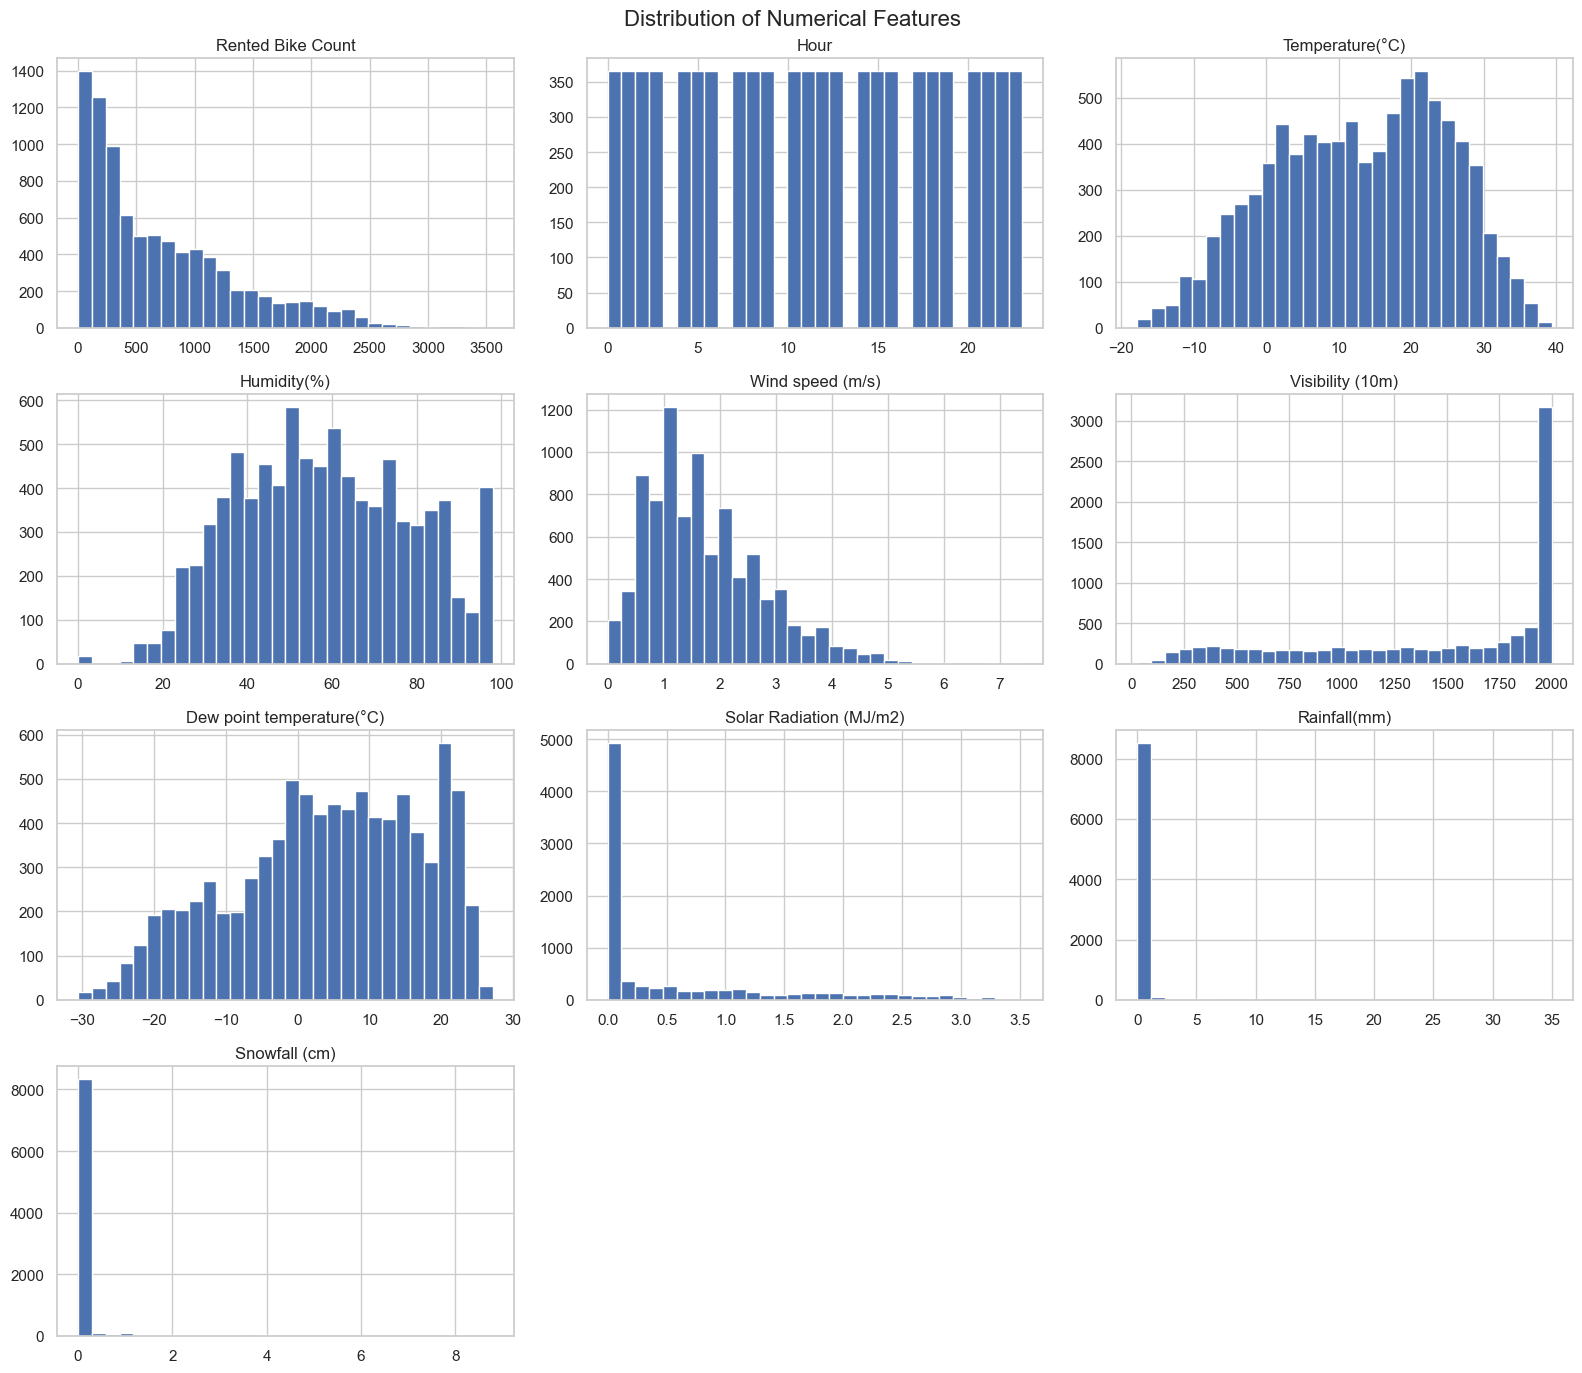

In [10]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].hist(
    figsize=(16, 14),
    bins=30
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### Observation

The numerical features have different ranges and distributions. Some variables show relatively concentrated values, while others have wider spreads. This indicates that the features differ in scale and variability, supporting the use of appropriate preprocessing before model training.

# 10. Correlation Analysis

A correlation heatmap is used to examine relationships between numerical features and the target variable.

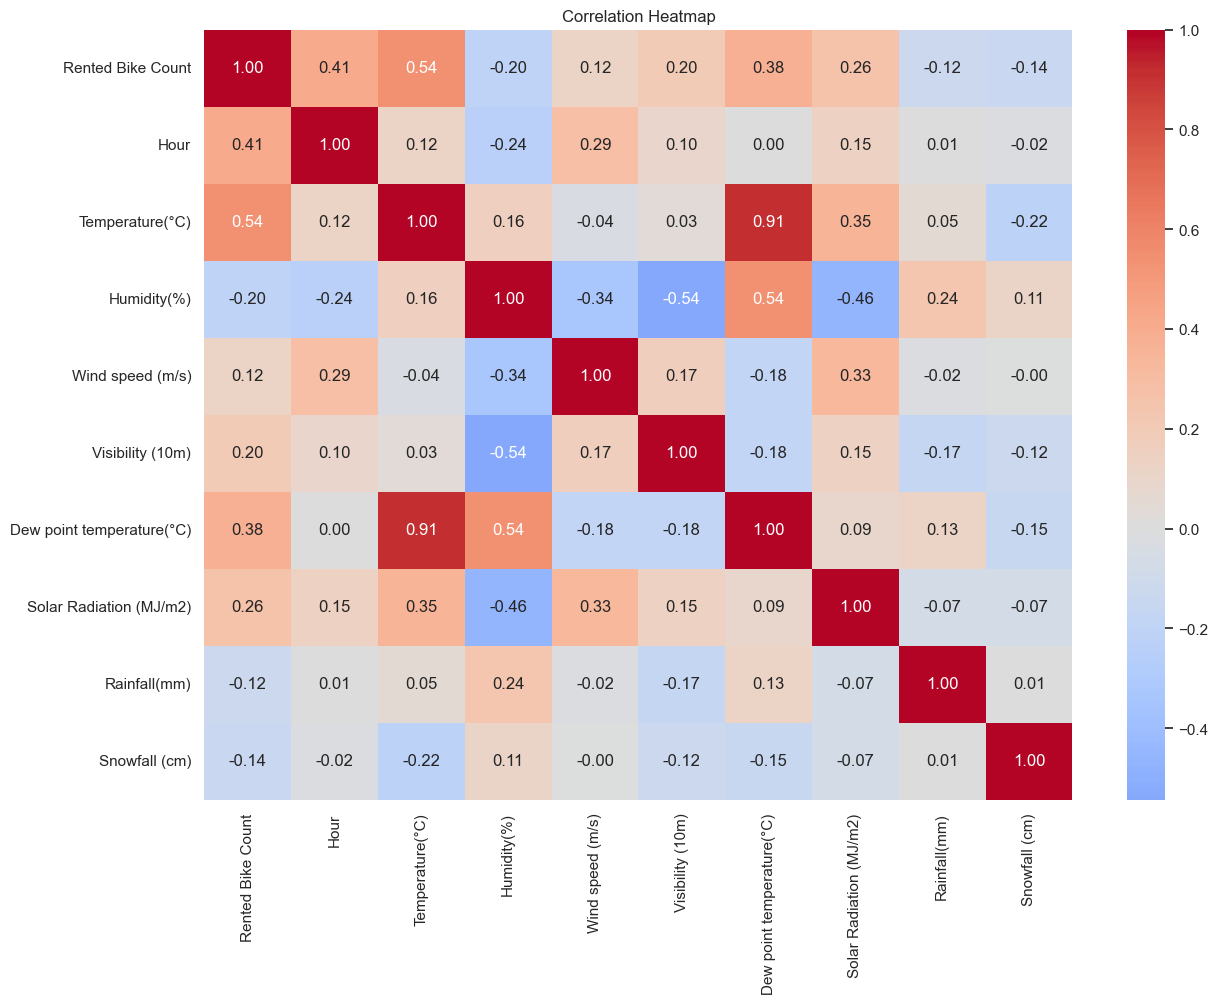

In [11]:
plt.figure(figsize=(14, 10))

correlation_matrix = df[numeric_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

### Observation

The correlation heatmap shows that some environmental and time-related variables have stronger relationships with rented bike demand than others. The relationships also indicate that certain input features are correlated with each other, which is useful for understanding the structure of the dataset.

# 11. Feature vs Target Relationships

Scatter plots are used to visually examine how selected numerical features relate to rented bike demand.

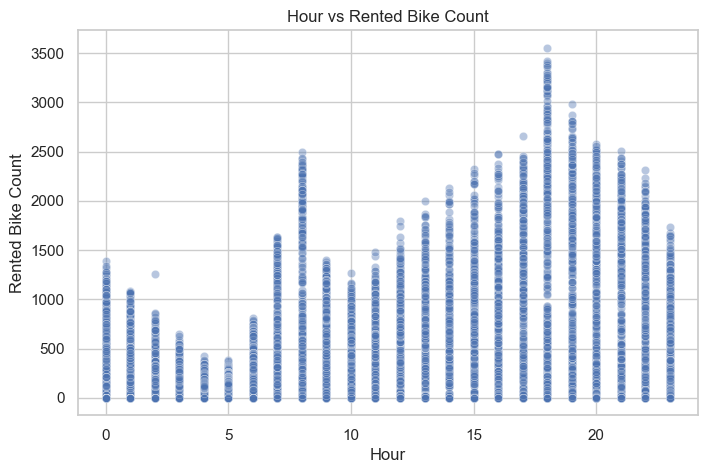

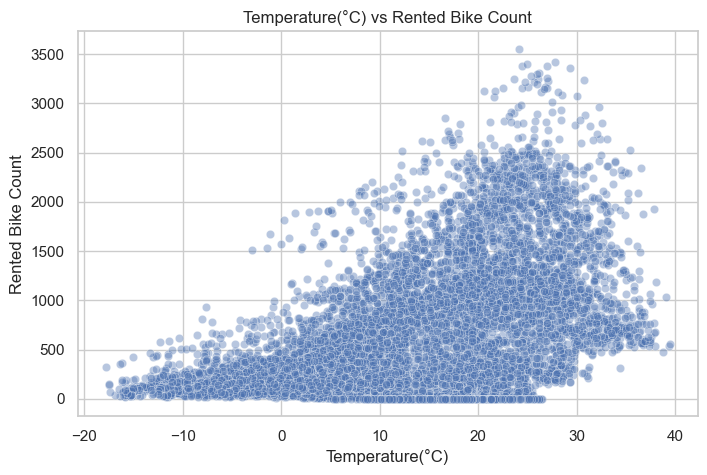

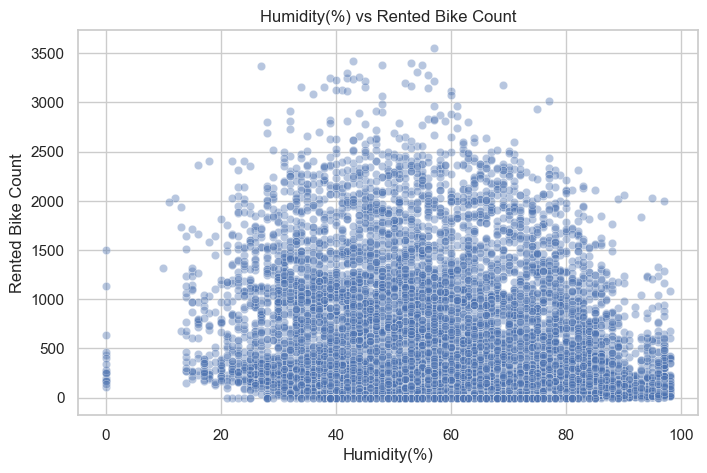

In [12]:
features_for_scatter = [
    "Hour",
    "Temperature(°C)",
    "Humidity(%)"
]

for feature in features_for_scatter:
    plt.figure(figsize=(8, 5))
    
    sns.scatterplot(
        data=df,
        x=feature,
        y=target,
        alpha=0.4
    )
    
    plt.title(f"{feature} vs {target}")
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.show()

### Observation

The scatter plots show that bike rental demand changes with the selected environmental features. The relationship is not completely linear, suggesting that nonlinear models may be useful for capturing more complex patterns in bike demand.

# 12. Outlier Visualisation

Boxplots are generated for important numerical variables to identify possible extreme observations and understand the spread of the data.

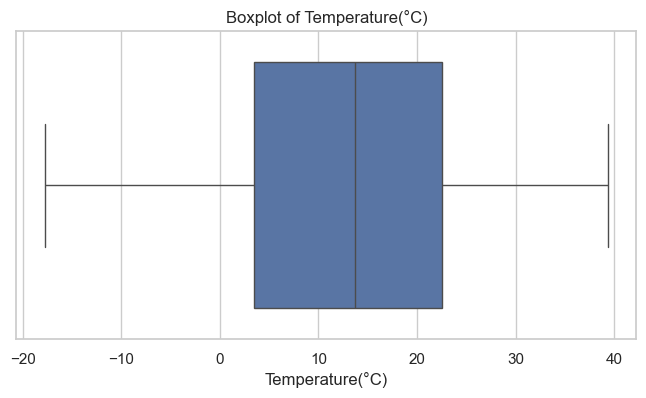

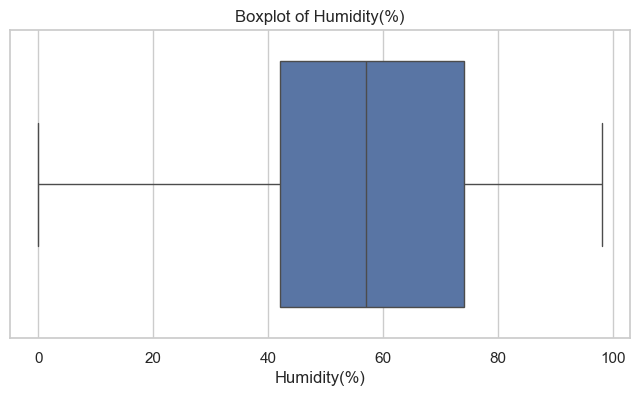

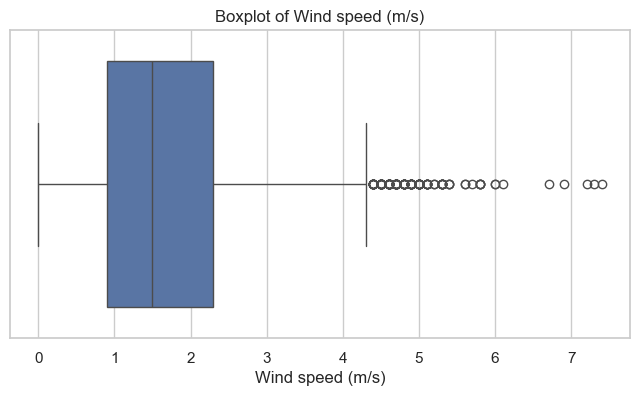

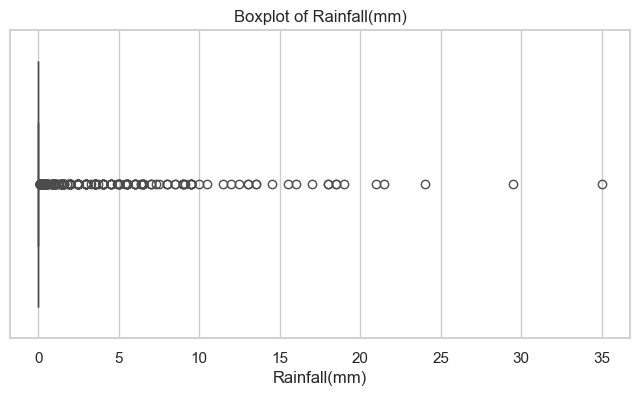

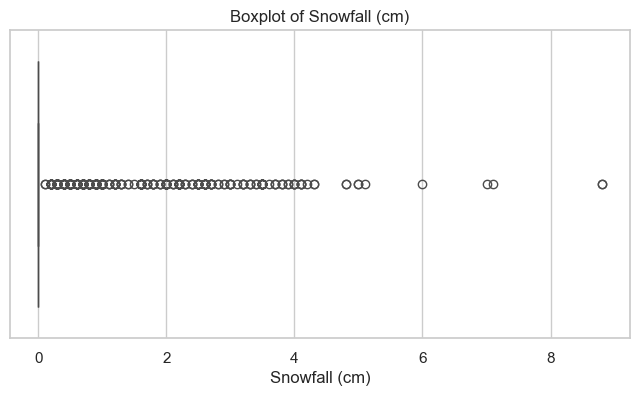

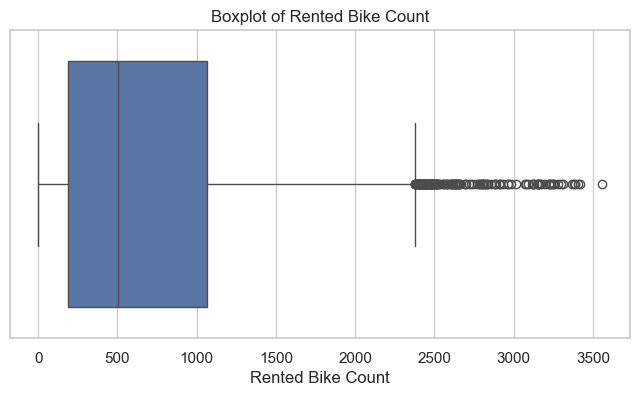

In [13]:
important_numeric = [
    "Temperature(°C)",
    "Humidity(%)",
    "Wind speed (m/s)",
    "Rainfall(mm)",
    "Snowfall (cm)",
    "Rented Bike Count"
]

for col in important_numeric:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot of {col}")
    plt.show()

### Observation

The boxplots show that several numerical variables contain observations that extend beyond the central range. These potential extreme values were further examined using the IQR-based outlier analysis.

# 13. Outlier Analysis

The IQR method is used to calculate the number and percentage of potential outliers in each numerical feature.

In [14]:
outlier_summary = []

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    
    outlier_summary.append({
        "Feature": col,
        "Outlier Count": count,
        "Outlier Percentage": round((count / len(df)) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df.sort_values(
    "Outlier Count",
    ascending=False
)

,Feature,Outlier Count,Outlier Percentage
7,Solar Radiation (MJ/m2),641,7.32
8,Rainfall(mm),528,6.03
9,Snowfall (cm),443,5.06
4,Wind speed (m/s),161,1.84
0,Rented Bike Count,158,1.80
1,Hour,0,0.00
5,Visibility (10m),0,0.00
3,Humidity(%),0,0.00
2,Temperature(°C),0,0.00
6,Dew point temperature(°C),0,0.00


# 14. Date Feature Engineering

The Date column is converted into separate time-related features such as year, month, day, and day of week.

A weekend indicator is also created.

In [15]:
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True
)

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

df["Weekend"] = (
    df["DayOfWeek"] >= 5
).astype(int)

# 15. Peak Hour Feature

A binary PeakHour feature is created to indicate whether an observation occurs during selected peak commuting hours.

In [16]:
df["PeakHour"] = df["Hour"].isin(
    [7, 8, 9, 17, 18, 19]
).astype(int)

df[["Hour", "PeakHour"]].head(10)

,Hour,PeakHour
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
5,5,0
6,6,0
7,7,1
8,8,1
9,9,1


# 16. Feature Interaction

An interaction feature between temperature and humidity is created to represent their combined effect.

In [17]:
df["Temperature_Humidity"] = (
    df["Temperature(°C)"] *
    df["Humidity(%)"]
)

df[
    [
        "Temperature(°C)",
        "Humidity(%)",
        "Temperature_Humidity"
    ]
].head()

,Temperature(°C),Humidity(%),Temperature_Humidity
0,-5.2,37,-192.4
1,-5.5,38,-209.0
2,-6.0,39,-234.0
3,-6.2,40,-248.0
4,-6.0,36,-216.0


# 17. Cyclic Time Encoding

Hour is converted into sine and cosine components so that the cyclic nature of time is represented in the model.

In [18]:
df["Hour_sin"] = np.sin(
    2 * np.pi * df["Hour"] / 24
)

df["Hour_cos"] = np.cos(
    2 * np.pi * df["Hour"] / 24
)

df[
    ["Hour", "Hour_sin", "Hour_cos"]
].head(10)

,Hour,Hour_sin,Hour_cos
0,0,0.000000,1.000000e+00
1,1,0.258819,9.659258e-01
2,2,0.500000,8.660254e-01
3,3,0.707107,7.071068e-01
4,4,0.866025,5.000000e-01
5,5,0.965926,2.588190e-01
6,6,1.000000,6.123234e-17
7,7,0.965926,-2.588190e-01
8,8,0.866025,-5.000000e-01
9,9,0.707107,-7.071068e-01


# 18. Final Feature Preparation

The original Date column is removed after extracting the useful date-related features.

In [19]:
df = df.drop(columns=["Date"])

print("New shape:", df.shape)
df.head()

New shape: (8760, 22)


,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),...,Functioning Day,Year,Month,Day,DayOfWeek,Weekend,PeakHour,Temperature_Humidity,Hour_sin,Hour_cos
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,...,Yes,2017,12,1,4,0,0,-192.4,0.000000,1.000000
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,...,Yes,2017,12,1,4,0,0,-209.0,0.258819,0.965926
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,...,Yes,2017,12,1,4,0,0,-234.0,0.500000,0.866025
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,...,Yes,2017,12,1,4,0,0,-248.0,0.707107,0.707107
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,...,Yes,2017,12,1,4,0,0,-216.0,0.866025,0.500000


# 19. Feature and Target Separation

The input features are stored in X and the target variable, Rented Bike Count, is stored in y.

In [20]:
X = df.drop(columns=[target])
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (8760, 21)
Target shape: (8760,)


# 20. Numerical and Categorical Features

The features are separated into numerical and categorical columns so that appropriate preprocessing can be applied to each type.

In [21]:
categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_columns = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numeric_columns)

Categorical columns:
['Seasons', 'Holiday', 'Functioning Day']

Numerical columns:
['Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Year', 'Month', 'Day', 'DayOfWeek', 'Weekend', 'PeakHour', 'Temperature_Humidity', 'Hour_sin', 'Hour_cos']


### Observation

The categorical feature distributions show how the observations are distributed across seasons, holiday status, and functioning-day status. These variables provide contextual information that may influence bike rental demand.

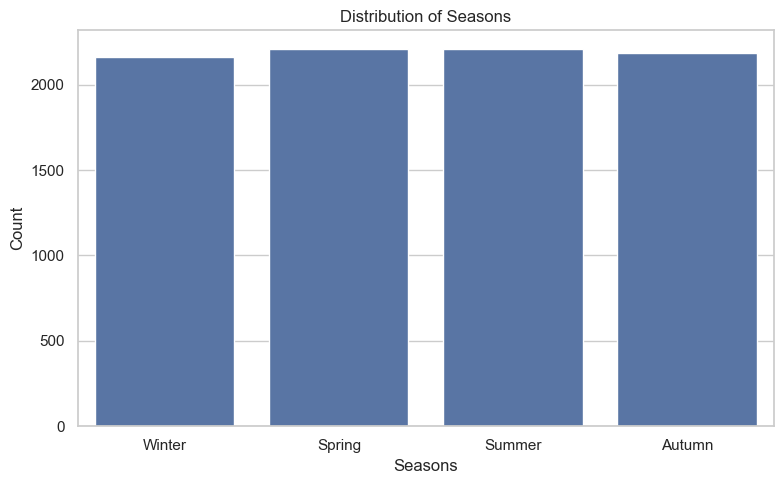

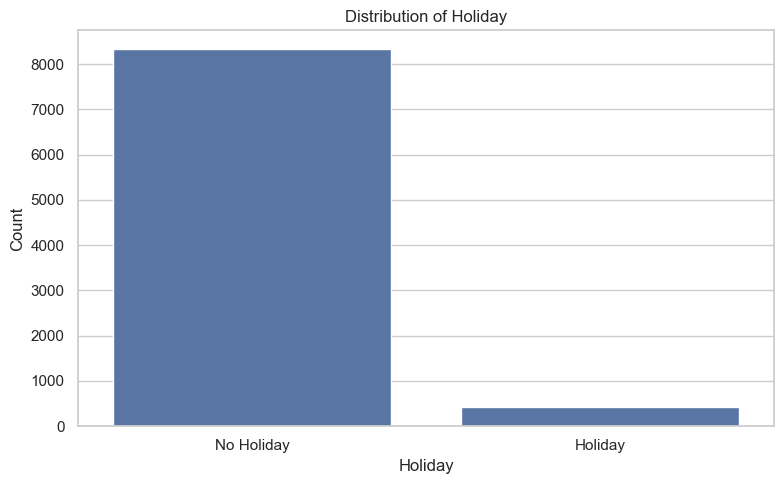

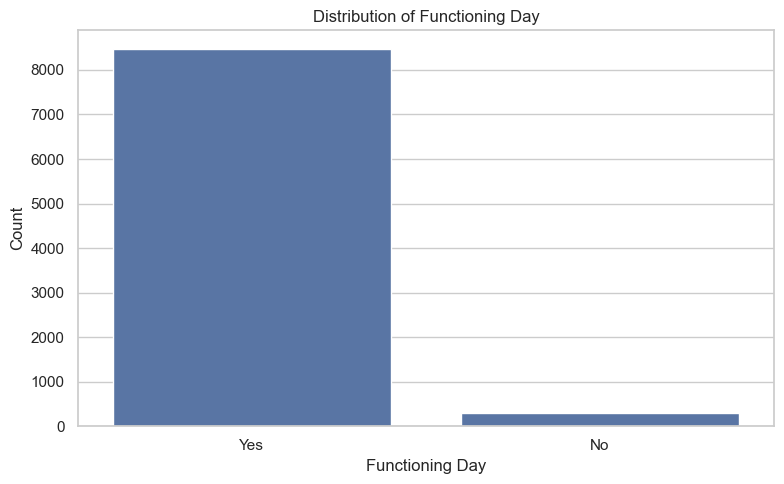

In [22]:
categorical_features = [
    "Seasons",
    "Holiday",
    "Functioning Day"
]

for feature in categorical_features:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=feature)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

### Observation

The categorical feature distributions show how the observations are distributed across seasons, holiday status, and functioning-day status. These variables provide contextual information that may influence bike rental demand.

# 21. Train-Test Split

The dataset is divided into 80% training data and 20% testing data.

The same split is used for comparing the regression models.

In [23]:
y_bins = pd.qcut(y, q=5, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y_bins
)

## Outlier Treatment

Outlier limits are calculated using the training data only. Extreme values in numerical input features are capped using training-derived IQR limits. The same training-derived limits are applied to the test data to avoid data leakage. The target variable is not modified.

In [24]:
# Outlier treatment using training data only

Q1_train = X_train[numeric_columns].quantile(0.25)
Q3_train = X_train[numeric_columns].quantile(0.75)

IQR_train = Q3_train - Q1_train

lower_train = Q1_train - 1.5 * IQR_train
upper_train = Q3_train + 1.5 * IQR_train

X_train[numeric_columns] = X_train[numeric_columns].clip(
    lower=lower_train,
    upper=upper_train,
    axis=1
)

X_test[numeric_columns] = X_test[numeric_columns].clip(
    lower=lower_train,
    upper=upper_train,
    axis=1
)

print("Outlier treatment completed using training-derived IQR limits.")

Outlier treatment completed using training-derived IQR limits.


# 22. Preprocessing Pipeline

A preprocessing pipeline is created.

For numerical features:
- Missing values are handled using median imputation.
- Features are standardised.

For categorical features:
- Missing values are handled using the most frequent value.
- One-hot encoding is applied.

In [25]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


# 23. Regression Models

Ten regression algorithms are implemented for comparison:

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. ElasticNet
5. Polynomial Regression
6. Decision Tree
7. Random Forest
8. Gradient Boosting
9. SVR
10. KNN Regressor

In [26]:
models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(),

    "Lasso Regression": Lasso(
        max_iter=10000
    ),

    "ElasticNet": ElasticNet(
        max_iter=10000
    ),

    "Polynomial Regression": Pipeline(
        steps=[
            ("poly", PolynomialFeatures(
                degree=2,
                include_bias=False
            )),
            ("regressor", Ridge())
        ]
    ),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "SVR": SVR(),

    "KNN": KNeighborsRegressor()
}

print("Number of models:", len(models))

Number of models: 10


# 24. Model Pipelines

A complete pipeline is created for every regression algorithm so that preprocessing and model training are performed consistently.

In [27]:
pipelines = {}

for name, model in models.items():
    
    pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

print("All model pipelines created.")

All model pipelines created.


# 25. Model Training and Evaluation

All ten regression models are trained using the training set.

The models are evaluated on the same test set using:

- R²
- RMSE
- MAE

This provides a direct comparison of their predictive performance.

In [28]:
results = []

trained_models = {}

for name, pipeline in pipelines.items():
    
    print(f"Training {name}...")
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )
    mae = mean_absolute_error(
        y_test,
        y_pred
    )
    
    results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })
    
    trained_models[name] = pipeline

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

results_df

Training Linear Regression...
Training Ridge Regression...
Training Lasso Regression...
Training ElasticNet...
Training Polynomial Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training SVR...
Training KNN...


,Model,R2,RMSE,MAE
0,Random Forest,0.937407,162.467022,94.619737
1,Gradient Boosting,0.874578,229.980187,156.258008
2,Decision Tree,0.859533,243.383371,135.280251
3,KNN,0.847641,253.476709,162.400114
4,Polynomial Regression,0.823354,272.932440,195.629064
5,Lasso Regression,0.552339,434.488788,322.477320
6,Ridge Regression,0.552216,434.548321,322.862580
7,Linear Regression,0.552187,434.562565,322.884765
8,ElasticNet,0.449142,481.973824,350.390823
9,SVR,0.300293,543.202485,371.568186


# 26. Formatted Model Results

The comparison table is formatted to make the R², RMSE, and MAE values easier to read.

In [29]:
results_df.style.format({
    "R2": "{:.4f}",
    "RMSE": "{:.2f}",
    "MAE": "{:.2f}"
})

,Model,R2,RMSE,MAE
0,Random Forest,0.9374,162.47,94.62
1,Gradient Boosting,0.8746,229.98,156.26
2,Decision Tree,0.8595,243.38,135.28
3,KNN,0.8476,253.48,162.40
4,Polynomial Regression,0.8234,272.93,195.63
5,Lasso Regression,0.5523,434.49,322.48
6,Ridge Regression,0.5522,434.55,322.86
7,Linear Regression,0.5522,434.56,322.88
8,ElasticNet,0.4491,481.97,350.39
9,SVR,0.3003,543.20,371.57


# 26. Formatted Model Results

The comparison table is formatted to make the R², RMSE, and MAE values easier to read.

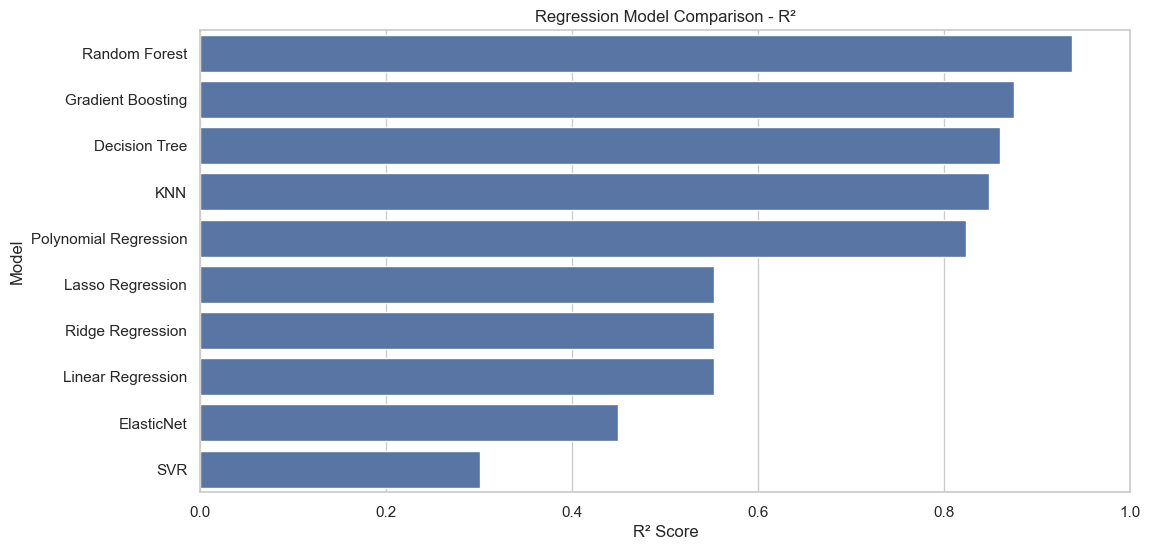

In [30]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="R2",
    y="Model"
)

plt.title("Regression Model Comparison - R²")
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.xlim(0, 1)

plt.show()

# 28. RMSE Model Comparison

The RMSE values of the regression models are visualised.

Lower RMSE indicates smaller prediction errors.

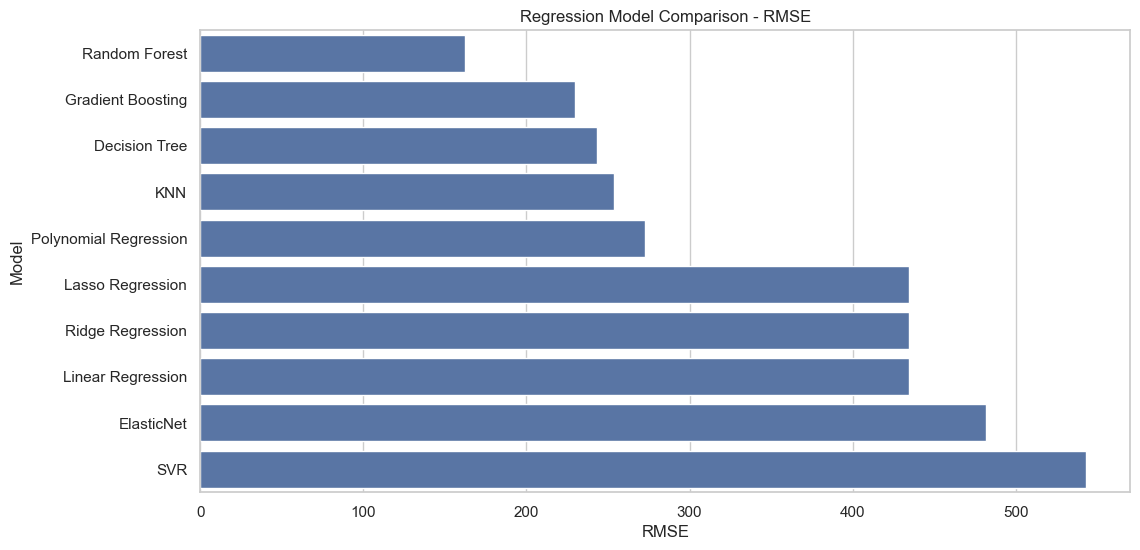

In [31]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="RMSE",
    y="Model"
)

plt.title("Regression Model Comparison - RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")

plt.show()

# 29. Random Forest Hyperparameter Tuning

Random Forest is tuned using GridSearchCV.

Five-fold cross-validation is used to evaluate different combinations of:
- Number of trees
- Maximum tree depth
- Minimum samples required for splitting

In [32]:
#Random Forest GridSearchCV
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

print("\nBest CV R²:")
print(rf_grid.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Random Forest parameters:
{'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best CV R²:
0.9189928650760745


# 30. Tuned Random Forest Evaluation

The tuned Random Forest model is evaluated on the held-out test set using R², RMSE, and MAE.

In [33]:
#Tuned Random Forest evaluation
rf_pred = rf_grid.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

print("Tuned Random Forest")
print("-------------------")
print("R²   :", round(rf_r2, 4))
print("RMSE :", round(rf_rmse, 2))
print("MAE  :", round(rf_mae, 2))

Tuned Random Forest
-------------------
R²   : 0.9371
RMSE : 162.89
MAE  : 95.25


# 31. Gradient Boosting Hyperparameter Tuning

Gradient Boosting is tuned using GridSearchCV.

The parameters explored include:
- Number of estimators
- Learning rate
- Maximum depth

In [34]:
#Gradient Boosting GridSearchCV
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)

gb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3]
}

gb_grid = GridSearchCV(
    gb_pipeline,
    param_grid=gb_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting parameters:")
print(gb_grid.best_params_)

print("\nBest CV R²:")
print(gb_grid.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Gradient Boosting parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}

Best CV R²:
0.8957804140836754


# 32. Tuned Gradient Boosting Evaluation

The tuned Gradient Boosting model is evaluated using R², RMSE, and MAE.

In [35]:
#Tuned Gradient Boosting evaluation
gb_pred = gb_grid.predict(X_test)

gb_r2 = r2_score(y_test, gb_pred)
gb_rmse = np.sqrt(
    mean_squared_error(y_test, gb_pred)
)
gb_mae = mean_absolute_error(
    y_test,
    gb_pred
)

print("Tuned Gradient Boosting")
print("-----------------------")
print("R²   :", round(gb_r2, 4))
print("RMSE :", round(gb_rmse, 2))
print("MAE  :", round(gb_mae, 2))

Tuned Gradient Boosting
-----------------------
R²   : 0.9048
RMSE : 200.36
MAE  : 133.35


# 32A. Hyperparameter Tuning Improvement

The effect of hyperparameter tuning is compared using the test-set R² score.

Random Forest achieved the same test-set R² before and after tuning, indicating no change in its held-out test performance.

Gradient Boosting improved its test-set R² after tuning, showing that the selected hyperparameters improved its predictive performance.

In [36]:
tuning_improvement = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "Before Tuning R2": [0.926614, 0.870737],
    "After Tuning R2": [0.926614, 0.904819]
})

tuning_improvement["R2 Improvement"] = (
    tuning_improvement["After Tuning R2"]
    - tuning_improvement["Before Tuning R2"]
)

tuning_improvement

,Model,Before Tuning R2,After Tuning R2,R2 Improvement
0,Random Forest,0.926614,0.926614,0.000000
1,Gradient Boosting,0.870737,0.904819,0.034082


# 33. Five-Fold Cross Validation

Five-fold cross-validation is performed on the tuned Random Forest and Gradient Boosting models to examine the stability of their R² scores across different folds.

In [37]:
#5-FOLD CROSS VALIDATION
best_two_models = [
    ("Random Forest", rf_grid.best_estimator_),
    ("Gradient Boosting", gb_grid.best_estimator_)
]

cv_results = []

for name, model in best_two_models:
    
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )
    
    cv_results.append({
        "Model": name,
        "Fold 1": scores[0],
        "Fold 2": scores[1],
        "Fold 3": scores[2],
        "Fold 4": scores[3],
        "Fold 5": scores[4],
        "Mean CV R2": scores.mean(),
        "Std CV R2": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

cv_df

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean CV R2,Std CV R2
0,Random Forest,0.921140,0.928635,0.909731,0.924661,0.910798,0.918993,0.007518
1,Gradient Boosting,0.897296,0.908011,0.876960,0.908192,0.888443,0.895780,0.011950


# 34. Selected Tuned Model

The tuned Random Forest and Gradient Boosting models are compared using their test-set R² scores, and the model with the higher R² is selected for the following diagnostic analysis.

In [38]:
if rf_r2 >= gb_r2:
    best_model_name = "Random Forest"
    best_model = rf_grid.best_estimator_
    best_predictions = rf_pred
else:
    best_model_name = "Gradient Boosting"
    best_model = gb_grid.best_estimator_
    best_predictions = gb_pred

print("Best tuned model:", best_model_name)

Best tuned model: Random Forest


# 35. Predicted vs Actual Analysis

The predicted values are plotted against the actual bike rental values.

A prediction closer to the diagonal reference line indicates closer agreement between predicted and actual values.

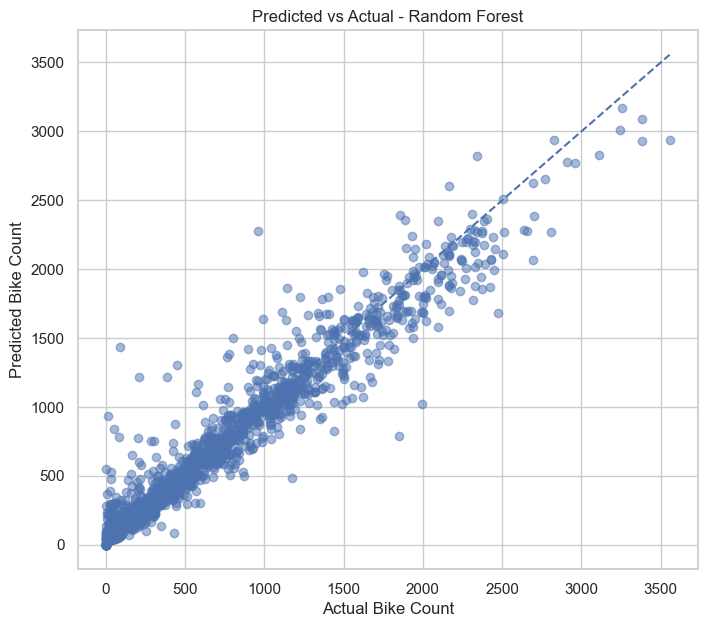

In [39]:
plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5
)

min_value = min(
    y_test.min(),
    best_predictions.min()
)

max_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Bike Count")
plt.ylabel("Predicted Bike Count")

plt.title(
    f"Predicted vs Actual - {best_model_name}"
)

plt.show()

# 36. Residual Analysis

Residuals represent the difference between the actual and predicted bike rental counts.

The residual plot is used to examine whether systematic patterns remain in the model errors.

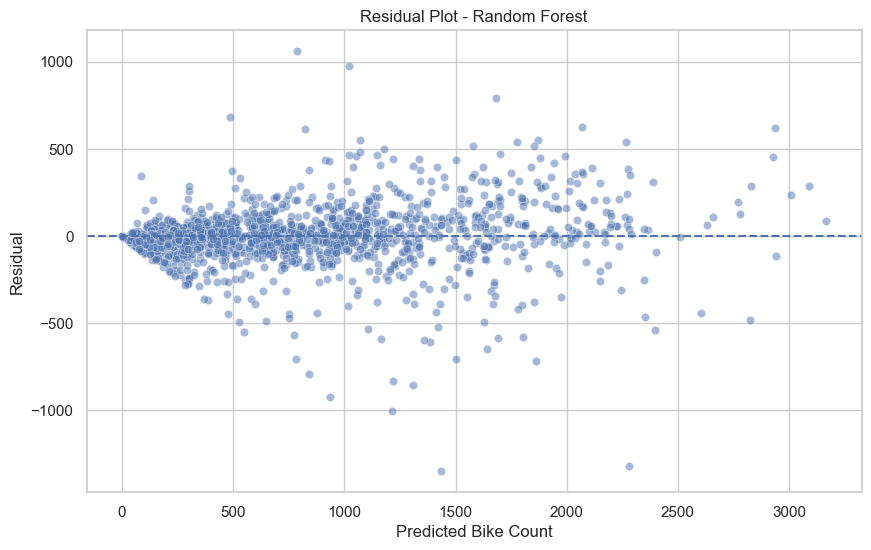

In [40]:
residuals = y_test - best_predictions

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=best_predictions,
    y=residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Bike Count")
plt.ylabel("Residual")

plt.title(
    f"Residual Plot - {best_model_name}"
)

plt.show()

# 37. Feature Importance

Feature importance from the tuned Random Forest model is examined to identify which features contribute most to predicting rented bike demand.

In [41]:
rf_model = rf_grid.best_estimator_

preprocessor_fitted = rf_model.named_steps[
    "preprocessor"
]

rf_estimator = rf_model.named_steps[
    "model"
]

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

importance = rf_estimator.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .head(15)
)

feature_importance_df

,Feature,Importance
1,num__Temperature(°C),0.295502
0,num__Hour,0.217260
2,num__Humidity(%),0.092316
6,num__Solar Radiation (MJ/m2),0.069442
16,num__Hour_sin,0.063362
25,cat__Functioning Day_Yes,0.044779
24,cat__Functioning Day_No,0.042522
17,num__Hour_cos,0.026174
12,num__DayOfWeek,0.022275
10,num__Month,0.017816


# 38. Top Feature Importances

The 15 most important features identified by Random Forest are visualised.

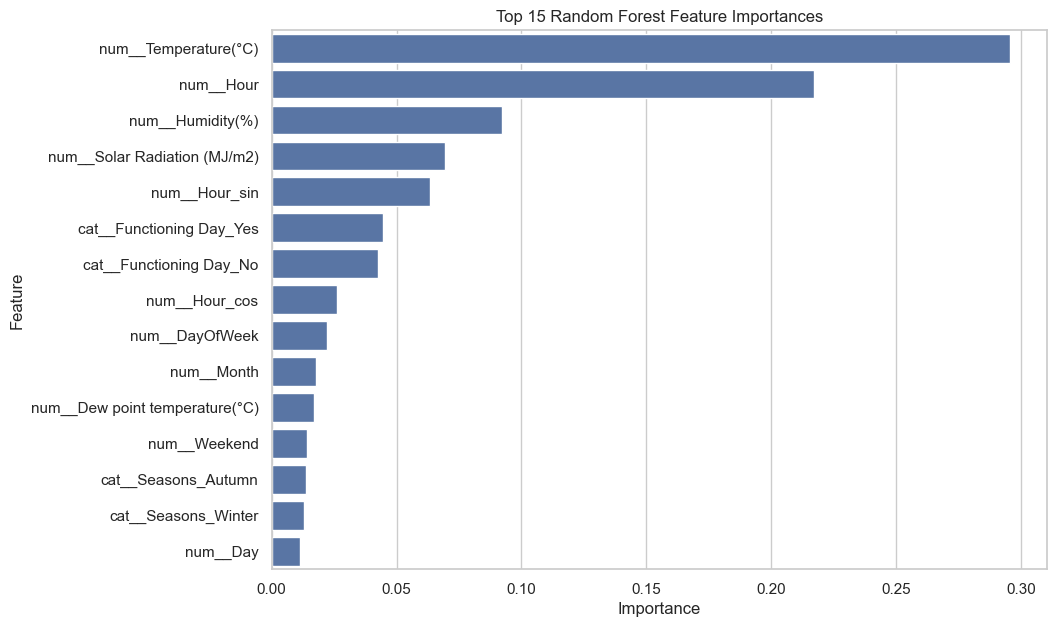

In [42]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Random Forest Feature Importances"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# 39. Final Tuned Model Comparison

The tuned Random Forest and Gradient Boosting models are compared using R², RMSE, and MAE.

In [43]:
final_comparison = pd.DataFrame({
    "Model": [
        "Random Forest - Tuned",
        "Gradient Boosting - Tuned"
    ],
    "R2": [
        rf_r2,
        gb_r2
    ],
    "RMSE": [
        rf_rmse,
        gb_rmse
    ],
    "MAE": [
        rf_mae,
        gb_mae
    ]
})

final_comparison.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

,Model,R2,RMSE,MAE
0,Random Forest - Tuned,0.937080,162.891285,95.247248
1,Gradient Boosting - Tuned,0.904801,200.363844,133.353969


# 40. Regression Conclusion

The Seoul Bike Sharing Demand dataset was analysed using an end-to-end regression workflow.

The workflow included dataset inspection, descriptive analysis, missing-value and duplicate checking, exploratory data analysis, outlier analysis, feature engineering, preprocessing, train-test splitting, and comparison of ten regression algorithms.

The ten models were evaluated using R², RMSE, and MAE. Random Forest and Gradient Boosting were subsequently selected for hyperparameter tuning using GridSearchCV with five-fold cross-validation.

The tuned models were further analysed using cross-validation, predicted-versus-actual analysis, residual analysis, and feature importance.

The final interpretation is based on the actual numerical results obtained from the experiments.